## 1. 초기 세팅

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
%pip install -q \
    "numpy==2.2.6" \
    "numba==0.61.2" \
    "anomalib==2.6.2" \
    jedi

In [5]:
%pip install --force-reinstall --no-cache-dir "numpy==2.1.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 323.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [6]:
import numpy as np
import numba
import torch
import anomalib

print("NumPy    :", np.__version__)
print("Numba    :", numba.__version__)
print("PyTorch  :", torch.__version__)
print("CUDA     :", torch.cuda.is_available())
print("Anomalib :", anomalib.__version__)

NumPy    : 2.1.3
Numba    : 0.61.2
PyTorch  : 2.11.0+cu128
CUDA     : True
Anomalib : 2.6.2


In [7]:
from anomalib.data import MVTecAD
from anomalib.models import Patchcore

print("Anomalib import success!")

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/dinomaly/components/layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


Anomalib import success!


## 2. MVTec AD bottle 데이터셋 구조 확인

In [8]:
from anomalib.data import MVTecAD

datamodule = MVTecAD(
    root="./datasets/MVTecAD",
    category="bottle",
)

In [9]:
datamodule.prepare_data()

In [10]:
!find ./datasets/MVTecAD/bottle -maxdepth 2 -type d | sort

./datasets/MVTecAD/bottle
./datasets/MVTecAD/bottle/ground_truth
./datasets/MVTecAD/bottle/ground_truth/broken_large
./datasets/MVTecAD/bottle/ground_truth/broken_small
./datasets/MVTecAD/bottle/ground_truth/contamination
./datasets/MVTecAD/bottle/test
./datasets/MVTecAD/bottle/test/broken_large
./datasets/MVTecAD/bottle/test/broken_small
./datasets/MVTecAD/bottle/test/contamination
./datasets/MVTecAD/bottle/test/good
./datasets/MVTecAD/bottle/train
./datasets/MVTecAD/bottle/train/good


In [11]:
from pathlib import Path

root = Path("./datasets/MVTecAD/bottle")

train_good = list((root / "train" / "good").glob("*.png"))
test_good = list((root / "test" / "good").glob("*.png"))
test_broken_large = list((root / "test" / "broken_large").glob("*.png"))
test_broken_small = list((root / "test" / "broken_small").glob("*.png"))
test_contamination = list((root / "test" / "contamination").glob("*.png"))

print("Train good       :", len(train_good))
print("Test good        :", len(test_good))
print("Broken large     :", len(test_broken_large))
print("Broken small     :", len(test_broken_small))
print("Contamination    :", len(test_contamination))

Train good       : 209
Test good        : 20
Broken large     : 20
Broken small     : 22
Contamination    : 21


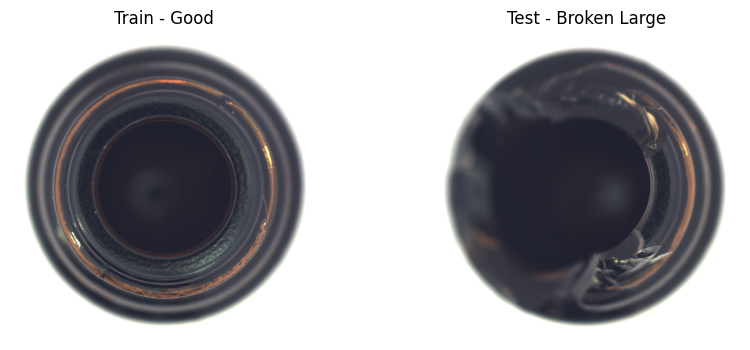

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

good_img = Image.open(train_good[0])
bad_img = Image.open(test_broken_large[0])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(good_img)
plt.title("Train - Good")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bad_img)
plt.title("Test - Broken Large")
plt.axis("off")

plt.show()

## 3. Ground Truth Mask 및 Pixel-level Anomaly 확인

1. ground_truth 폴더 확인

In [13]:
from pathlib import Path

root = Path("./datasets/MVTecAD/bottle")

In [14]:
!find ./datasets/MVTecAD/bottle/ground_truth -maxdepth 2 -type d | sort

./datasets/MVTecAD/bottle/ground_truth
./datasets/MVTecAD/bottle/ground_truth/broken_large
./datasets/MVTecAD/bottle/ground_truth/broken_small
./datasets/MVTecAD/bottle/ground_truth/contamination


2. 이미지, mask 파일 대응 확인

In [15]:
broken_images = sorted(
    (root / "test" / "broken_large").glob("*.png")
)

broken_masks = sorted(
    (root / "ground_truth" / "broken_large").glob("*.png")
)

print("Image:", broken_images[0].name)
print("Mask :", broken_masks[0].name)

Image: 000.png
Mask : 000_mask.png


3. mask 단독 시각화

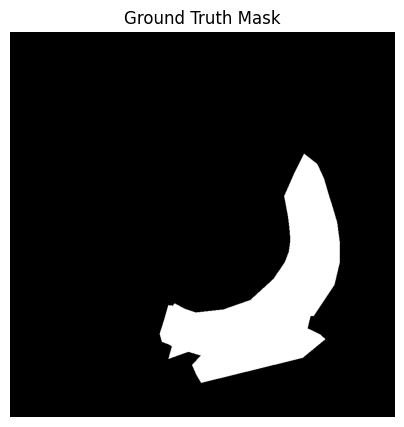

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

mask_img = Image.open(broken_masks[0])

plt.figure(figsize=(5, 5))
plt.imshow(mask_img, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

4. 원본 + mask 비교

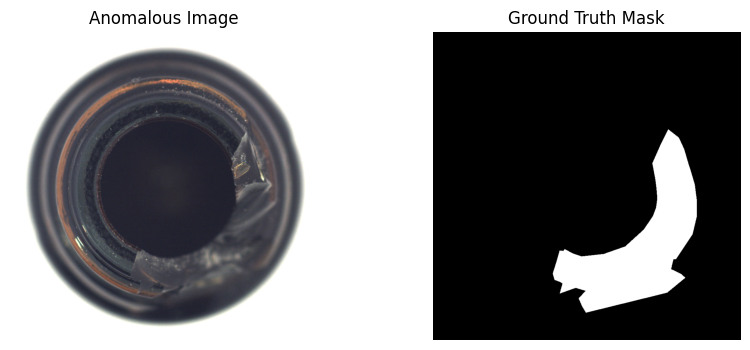

In [17]:
bad_img = Image.open(broken_images[0])
mask_img = Image.open(broken_masks[0])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(bad_img)
plt.title("Anomalous Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_img, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

5. mask overlay

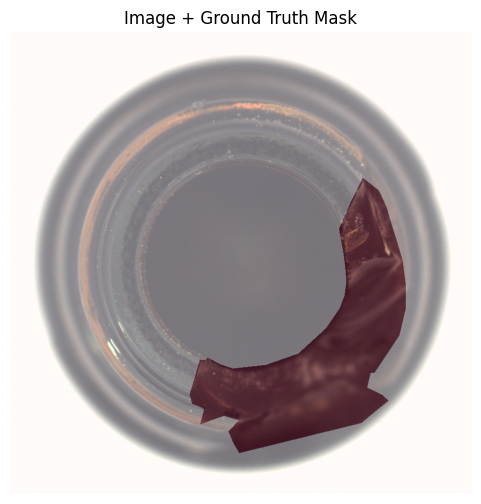

In [18]:
import numpy as np

bad_array = np.array(bad_img)
mask_array = np.array(mask_img)

plt.figure(figsize=(6, 6))

plt.imshow(bad_array)
plt.imshow(mask_array, cmap="Reds", alpha=0.4)

plt.title("Image + Ground Truth Mask")
plt.axis("off")
plt.show()

## 4. PatchCore 모델 구성 및 정상 특징 학습

1. PatchCore와 Engine 불러오기

In [19]:
from anomalib.models import Patchcore
from anomalib.engine import Engine

2. PatchCore 전처리 설정

In [20]:
pre_processor = Patchcore.configure_pre_processor(
    image_size=(256, 256),
    center_crop_size=(256, 256),
)

3. PatchCore 모델 생성

In [21]:
model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    pre_trained=True,
    coreset_sampling_ratio=0.1,
    num_neighbors=9,
    pre_processor=pre_processor,
)

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


4. 모델 구조 확인

In [22]:
print(model)

Patchcore(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          CenterCrop(size=(256, 256))
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          ExportableCenterCrop(size=[256, 256])
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PatchcoreModel(
  

5. Engine 생성

In [23]:
engine = Engine(
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)

6. PatchCore 정상 특징 학습

In [24]:
engine.fit(
    model=model,
    datamodule=datamodule,
)

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to 

In [25]:
memory_bank = model.model.memory_bank

print("Memory bank shape :", memory_bank.shape)
print("Feature dtype     :", memory_bank.dtype)
print("Stored on         :", memory_bank.device)

Memory bank shape : torch.Size([21401, 1536])
Feature dtype     : torch.float32
Stored on         : cpu
